<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [1]:
# %pip install git+https://github.com/alemartinello/dstapi
# %pip install fredapi

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [3]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [5]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [6]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

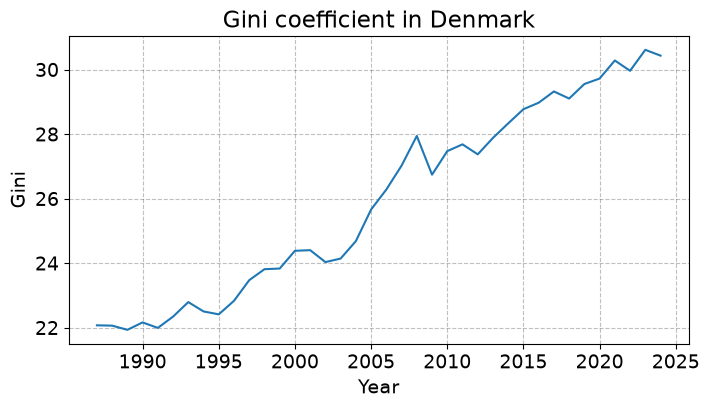

In [7]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [8]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [9]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [10]:
df=df.drop(columns=['KOMMUNEDK','DECILGEN'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,income
year,
1987,68786
1987,77577
1987,85361
1987,92777
1987,100691


### 1.2 Prediction

### 1.3 Municipalities

### 1.4 Extension

<h2> 2 Simulating the income distribution

### 2.1 The model

### 2.2 Simulate the income distribution

### 2.3 Compute the Gini coefficient

### 2.4 What drives inequality?

### 2.5 Extension: more risk